Tmax = 62.96964 degC at Tair=40, Vair=0.75, sgap=1
Tmin = 37.97526 degC at Tair=20, Vair=2.0, sgap=5
s_gap = 3 mm corner Tmax values:
  top-left:     T_air=20 degC, V_air=2 m/s, Tmax=38.20 degC
  bottom-left:  T_air=20 degC, V_air=0.75 m/s, Tmax=42.14 degC
  top-right:    T_air=40 degC, V_air=2 m/s, Tmax=58.43 degC
  bottom-right: T_air=40 degC, V_air=0.75 m/s, Tmax=62.48 degC
Air-cooling scan PNG saved to: d:\eBATS\out\C0004\Tmax_dT_Efan_AC_BTMS_SCAN.png
Air-cooling scan PDF saved to: d:\eBATS\out\C0004\Tmax_dT_Efan_AC_BTMS_SCAN.pdf


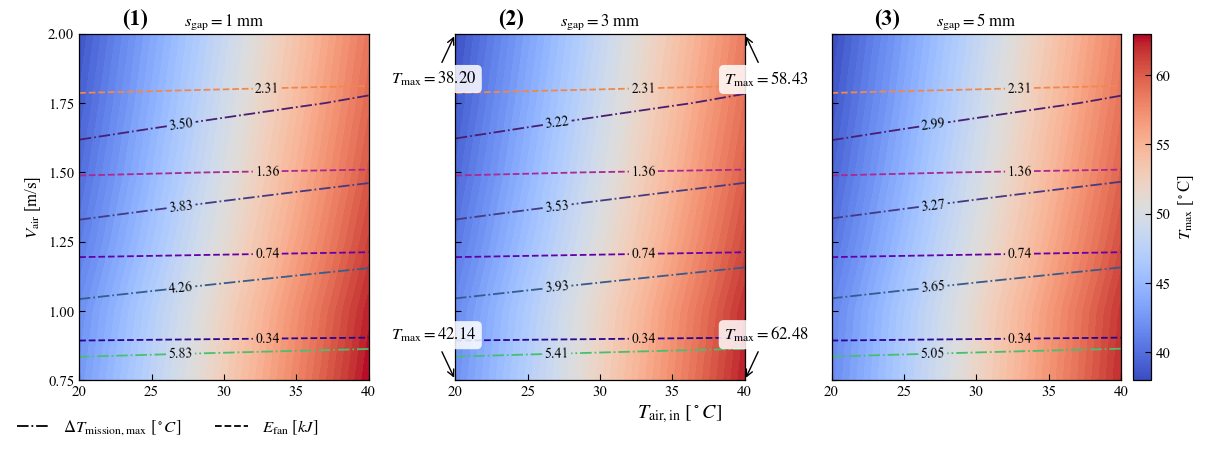

In [15]:
# ============================================================
# Air-cooled BTMS parametric scan
# Heat map: Tmax
# Contours: DeltaTmax and cumulative fan energy
# ============================================================

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ============================================================
# 1. File path and data
# ============================================================

root_dir = os.path.abspath("../..")
CASE_ID = "C0004"

data_file = os.path.join(root_dir, "data", CASE_ID, "C0004R02_PARK25_AC_1D_SCAN.xlsx")
sheet_name = "Parameter scan"

data = pd.read_excel(data_file, sheet_name=sheet_name)

key_spacing = "s_gap_mm"
key_x = "T_air_in_C"
key_y = "V_air_m_s"
key_Tmax = "Tmax_mission_C"
key_dT = "DeltaT_mission_max_C"
key_Efan = "E_fan_cumulative_J"

SPACING_TO_PLOT = [1, 3, 5]

required_columns = [key_spacing, key_x, key_y, key_Tmax, key_dT, key_Efan]
missing_columns = [c for c in required_columns if c not in data.columns]

if missing_columns:
    raise KeyError(f"Missing columns: {missing_columns}")

thermal_data = data[data[key_spacing].isin(SPACING_TO_PLOT)].copy()
thermal_data['E_fan_cumulative_kJ'] = thermal_data[key_Efan] / 1000.0
key_Efan_plot = 'E_fan_cumulative_kJ'

# ============================================================
# 2. Figure style
# ============================================================

base_fontsize = 12

plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "font.size": base_fontsize,
    "axes.labelsize": base_fontsize,
    "axes.titlesize": base_fontsize,
    "xtick.labelsize": base_fontsize * 0.9,
    "ytick.labelsize": base_fontsize * 0.9,
    "axes.linewidth": 0.9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.unicode_minus": False
})

def label_fmt(x):
    return f"{x:.2f}"

# ============================================================
# 3. Global Tmax range
# ============================================================

T_max = thermal_data[key_Tmax].max()
T_min = thermal_data[key_Tmax].min()

T_max_row = thermal_data.loc[thermal_data[key_Tmax].idxmax()]
T_min_row = thermal_data.loc[thermal_data[key_Tmax].idxmin()]

print(f"Tmax = {T_max:.5f} degC at Tair={T_max_row[key_x]}, Vair={T_max_row[key_y]}, sgap={T_max_row[key_spacing]}")
print(f"Tmin = {T_min:.5f} degC at Tair={T_min_row[key_x]}, Vair={T_min_row[key_y]}, sgap={T_min_row[key_spacing]}")

# ============================================================
# 4. Colormaps
# ============================================================

cmap_T = sns.color_palette("coolwarm", as_cmap=True)
cmap_dT = sns.color_palette("viridis", as_cmap=True)
cmap_Efan = sns.color_palette("plasma", as_cmap=True)

# ============================================================
# 5. Contour positions
# ============================================================

V_TARGET_EFAN = np.array([0.90, 1.20, 1.50, 1.80])
V_TARGET_DT = np.array([0.85, 1.10, 1.40, 1.70])

def levels_from_target_y(Z, y_values, y_targets, decimals=2):
    profile = np.nanmean(Z, axis=1)
    y_targets = np.clip(np.asarray(y_targets, dtype=float), y_values.min(), y_values.max())
    levels = np.interp(y_targets, y_values, profile)
    return np.sort(np.unique(np.round(levels, decimals)))

# ============================================================
# 6. Plot
# ============================================================

fig, ax_dict = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

# Increase the horizontal spacing between subplots so the Tmax annotations
# beside the middle panel are not covered by the third subplot.
plt.subplots_adjust(hspace=0.3, wspace=0.30)

for i, s_gap in enumerate(SPACING_TO_PLOT):

    ax = ax_dict[i]
    data_gap = thermal_data[np.isclose(thermal_data[key_spacing], s_gap)].copy()

    x_values = np.sort(data_gap[key_x].unique())
    y_values = np.sort(data_gap[key_y].unique())

    Z_values_T = data_gap.pivot(index=key_y, columns=key_x, values=key_Tmax).reindex(index=y_values, columns=x_values).values
    Z_values_dT = data_gap.pivot(index=key_y, columns=key_x, values=key_dT).reindex(index=y_values, columns=x_values).values
    Z_values_Efan = data_gap.pivot(index=key_y, columns=key_x, values=key_Efan_plot).reindex(index=y_values, columns=x_values).values

    if np.isnan(Z_values_T).any() or np.isnan(Z_values_dT).any() or np.isnan(Z_values_Efan).any():
        raise ValueError(f"Incomplete T_air-V_air grid for s_gap = {s_gap} mm")

    levels_dT = levels_from_target_y(Z_values_dT, y_values, V_TARGET_DT, decimals=2)
    levels_Efan = levels_from_target_y(Z_values_Efan, y_values, V_TARGET_EFAN, decimals=2)

    ax.contourf(x_values, y_values, Z_values_T, levels=50, cmap=cmap_T, vmin=T_min, vmax=T_max)

    cs_dT = ax.contour(x_values, y_values, Z_values_dT, levels=levels_dT, cmap=cmap_dT, vmin=Z_values_dT.min(), vmax=Z_values_dT.max(), linestyles="dashdot", linewidths=1.3)
    cs_Efan = ax.contour(x_values, y_values, Z_values_Efan, levels=levels_Efan, cmap=cmap_Efan, vmin=Z_values_Efan.min(), vmax=Z_values_Efan.max(), linestyles="dashed", linewidths=1.3)

    x_label_dT = x_values.min() + 0.35 * (x_values.max() - x_values.min())
    x_label_Efan = x_values.min() + 0.65 * (x_values.max() - x_values.min())

    manual_dT = [(x_label_dT, y) for y in V_TARGET_DT]
    manual_Efan = [(x_label_Efan, y) for y in V_TARGET_EFAN]

    ax.clabel(cs_dT, inline=True, fontsize=10, fmt=label_fmt, colors="black", manual=manual_dT)
    ax.clabel(cs_Efan, inline=True, fontsize=10, fmt=label_fmt, colors="black", manual=manual_Efan)

    if s_gap == 3:

        # Read the four corner values directly from the current Excel data.
        # This avoids top/bottom reversal when the V_air scan range changes.
        x_min = x_values.min()
        x_max = x_values.max()
        y_min = y_values.min()
        y_max = y_values.max()

        def get_corner_Tmax(T_air_value, V_air_value):
            corner = data_gap[np.isclose(data_gap[key_x], T_air_value) & np.isclose(data_gap[key_y], V_air_value)]
            if len(corner) != 1:
                raise ValueError(f"Expected one corner point for T_air={T_air_value}, V_air={V_air_value}, s_gap={s_gap} mm, but found {len(corner)}.")
            return float(corner[key_Tmax].iloc[0])

        T_top_left = get_corner_Tmax(x_min, y_max)
        T_bottom_left = get_corner_Tmax(x_min, y_min)
        T_top_right = get_corner_Tmax(x_max, y_max)
        T_bottom_right = get_corner_Tmax(x_max, y_min)

        annotation_style = dict(arrowprops=dict(arrowstyle="->", color="black", lw=1.0, shrinkA=2, shrinkB=2), fontsize=base_fontsize, bbox=dict(boxstyle="round,pad=0.3", edgecolor="none", facecolor="white", alpha=0.85), zorder=10, annotation_clip=False)

        ax.annotate(fr"$T_\mathrm{{max}}={T_top_left:.2f}$", xy=(x_min, y_max), xytext=(-46, -26), textcoords="offset points", ha="left", va="top", **annotation_style)
        ax.annotate(fr"$T_\mathrm{{max}}={T_bottom_left:.2f}$", xy=(x_min, y_min), xytext=(-46, 26), textcoords="offset points", ha="left", va="bottom", **annotation_style)
        ax.annotate(fr"$T_\mathrm{{max}}={T_top_right:.2f}$", xy=(x_max, y_max), xytext=(46, -26), textcoords="offset points", ha="right", va="top", **annotation_style)
        ax.annotate(fr"$T_\mathrm{{max}}={T_bottom_right:.2f}$", xy=(x_max, y_min), xytext=(46, 26), textcoords="offset points", ha="right", va="bottom", **annotation_style)

        print(f"s_gap = {s_gap:g} mm corner Tmax values:")
        print(f"  top-left:     T_air={x_min:g} degC, V_air={y_max:g} m/s, Tmax={T_top_left:.2f} degC")
        print(f"  bottom-left:  T_air={x_min:g} degC, V_air={y_min:g} m/s, Tmax={T_bottom_left:.2f} degC")
        print(f"  top-right:    T_air={x_max:g} degC, V_air={y_max:g} m/s, Tmax={T_top_right:.2f} degC")
        print(f"  bottom-right: T_air={x_max:g} degC, V_air={y_min:g} m/s, Tmax={T_bottom_right:.2f} degC")

    ax.set_title(rf"$s_\mathrm{{gap}}={s_gap:g}\ \mathrm{{mm}}$")
    ax.set_xticks(x_values)
    ax.set_yticks(y_values)

    if i == 0:
        ax.set_ylabel(r"$V_\mathrm{air}$ [m/s]")

# ============================================================
# 7. Subfigure labels
# ============================================================

panel_labels = ["(1)", "(2)", "(3)"]
panel_label_artists = [ax.text(0.0, 1.01, panel_label, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, fontweight="bold", fontfamily="Times New Roman", clip_on=False) for ax, panel_label in zip(ax_dict, panel_labels)]
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
PANEL_LABEL_GAP_PT = 40.0  # Horizontal gap between (1)/(2)/(3) and the title; increase this value if more spacing is desired
panel_label_gap_px = PANEL_LABEL_GAP_PT * fig.dpi / 72.0
for ax, panel_label_artist in zip(ax_dict, panel_label_artists):
    title_bbox = ax.title.get_window_extent(renderer=renderer)
    label_bbox = panel_label_artist.get_window_extent(renderer=renderer)
    panel_label_x_disp = title_bbox.x0 - panel_label_gap_px - label_bbox.width
    panel_label_x_axes = ax.transAxes.inverted().transform((panel_label_x_disp, title_bbox.y0))[0]
    panel_label_artist.set_x(panel_label_x_axes)
fig.canvas.draw()

# ============================================================
# 8. Shared labels and legend
# ============================================================

fig.supxlabel(r"$T_\mathrm{air,in}\ [^\circ C]$")

legend_elements = [
    Line2D([0], [0], color="black", lw=1.3, linestyle="dashdot", label=r"$\Delta T_\mathrm{mission,max}\ [^\circ C]$"),
    Line2D([0], [0], color="black", lw=1.3, linestyle="dashed", label=r"$E_\mathrm{fan}\ [kJ]$")
]

fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=base_fontsize, frameon=False, bbox_to_anchor=(0.18, -0.05))

# ============================================================
# 9. Shared Tmax colorbar
# ============================================================

sm = plt.cm.ScalarMappable(cmap=cmap_T, norm=Normalize(vmin=T_min, vmax=T_max))
sm.set_array([])

fig.colorbar(sm, ax=ax_dict, label=r"$T_{\max}$ [$^\circ$C]", pad=0.01)

# ============================================================
# 10. Save PNG and PDF
# ============================================================

output_folder = os.path.join(root_dir, "out", CASE_ID)
os.makedirs(output_folder, exist_ok=True)

output_file_png = os.path.join(output_folder, "Tmax_dT_Efan_AC_BTMS_SCAN.png")
output_file_pdf = os.path.join(output_folder, "Tmax_dT_Efan_AC_BTMS_SCAN.pdf")

fig.savefig(output_file_png, dpi=300, bbox_inches="tight")
fig.savefig(output_file_pdf, format="pdf", bbox_inches="tight")

print("Air-cooling scan PNG saved to:", output_file_png)
print("Air-cooling scan PDF saved to:", output_file_pdf)

plt.show()


Project root: d:\eBATS
plot_util: d:\eBATS\lib\plot_util.py
Tmax range: [np.float64(35.97571315984933), np.float64(64.96919286479452)]
DeltaT range: [np.float64(2.3704259511748806), np.float64(7.2535298504529555)]
Efan range: [0.0, 3.5]
Air-cooling detailed scan PNG saved to: d:\eBATS\out\C0004\C0004R02_PARK25_AC_1D_SCAN_details.png
Air-cooling detailed scan PDF saved to: d:\eBATS\out\C0004\C0004R02_PARK25_AC_1D_SCAN_details.pdf


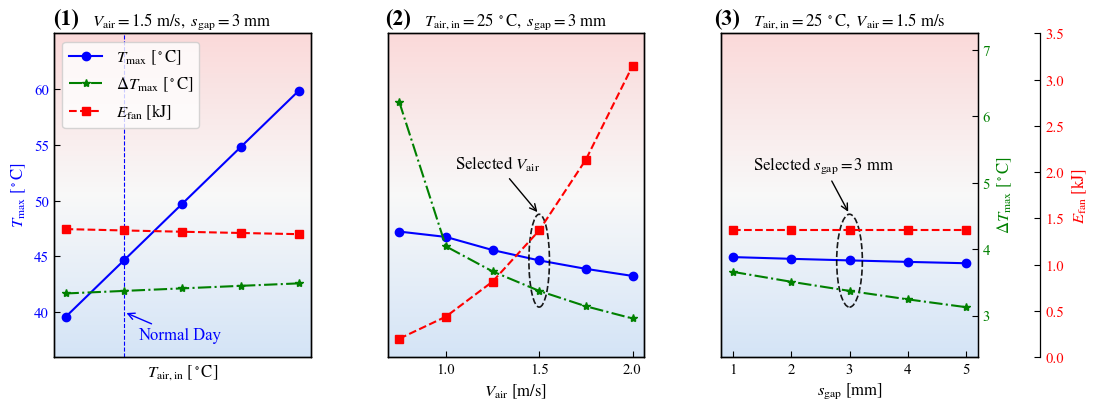

In [16]:
# ============================================================
# Detailed parametric trends for the air-cooled BTMS
# Three subfigures:
# 1) inlet air temperature
# 2) inlet air velocity
# 3) cell gap
# ============================================================

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ============================================================
# 1. Project path and local plotting utilities
# ============================================================

root_dir = os.path.abspath("../..")

if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

plot_util_file = os.path.join(root_dir, "lib", "plot_util.py")

if not os.path.exists(plot_util_file):
    raise FileNotFoundError(f"Cannot find plot_util.py: {plot_util_file}")

import lib.plot_util as plot_util

print("Project root:", root_dir)
print("plot_util:", plot_util_file)

# ============================================================
# 2. Read parameter-scan data
# ============================================================

CASE_ID = "C0004"

data_file = os.path.join(root_dir, "data", CASE_ID, "C0004R02_PARK25_AC_1D_SCAN.xlsx")
sheet_name = "Parameter scan"

if not os.path.exists(data_file):
    raise FileNotFoundError(f"Cannot find scan data: {data_file}")

data = pd.read_excel(data_file, sheet_name=sheet_name)

# ============================================================
# 3. Plot style
# ============================================================

base_fontsize = 12

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

# ============================================================
# 4. Variable definitions
# ============================================================

y1_name = 'Tmax_mission_C'
y2_name = 'DeltaT_mission_max_C'
y3_name = 'E_fan_cumulative_kJ'

plot_data = data.copy()
plot_data[y3_name] = plot_data['E_fan_cumulative_J'] / 1000.0

required_columns = ['V_air_m_s', 'T_air_in_C', 's_gap_mm', y1_name, y2_name, 'E_fan_cumulative_J']
missing_columns = [c for c in required_columns if c not in plot_data.columns]

if missing_columns:
    raise KeyError(f"Missing columns: {missing_columns}")

# ============================================================
# 5. Common y-axis ranges
# ============================================================

def get_plot_range(values, padding_ratio=0.08):
    values = np.asarray(values, dtype=float)
    value_min = np.nanmin(values)
    value_max = np.nanmax(values)
    value_span = value_max - value_min
    padding = value_span * padding_ratio if value_span > 0.0 else max(abs(value_max) * padding_ratio, 0.1)
    return [value_min - padding, value_max + padding]

Tbmax_range = get_plot_range(plot_data[y1_name])
dTbmax_range = get_plot_range(plot_data[y2_name])
Efan_range = [0.0, 3.5]

print("Tmax range:", Tbmax_range)
print("DeltaT range:", dTbmax_range)
print("Efan range:", Efan_range)

# ============================================================
# 6. Curve styles
# ============================================================

curve_artists = {
    y1_name: dict(color='blue', label=r"$T_\mathrm{max}\ [^\circ \mathrm{C}]$", ls='-', marker='o'),
    y2_name: dict(color='green', label=r"$\Delta T_\mathrm{max}\ [^\circ \mathrm{C}]$", ls='-.', marker='*'),
    y3_name: dict(color='red', label=r"$E_\mathrm{fan}\ [\mathrm{kJ}]$", ls='--', marker='s')
}

# ============================================================
# 7. Selected operating conditions
# ============================================================

T_air_selected = 25.0
V_air_selected = 1.50
s_gap_selected = 3.0

# ============================================================
# 8. Create figure
# ============================================================

fig, ax_all = plt.subplots(1, 3, figsize=(12, 4.5))

# ============================================================
# Subfigure 1
# T_air,in sensitivity
# Fixed V_air = 1.5 m/s and s_gap = 3 mm
# ============================================================

filtered_data = plot_data[np.isclose(plot_data['V_air_m_s'], V_air_selected) & np.isclose(plot_data['s_gap_mm'], s_gap_selected)].copy()
filtered_data = filtered_data.sort_values('T_air_in_C')

if filtered_data.empty:
    raise ValueError(f"No data found for V_air={V_air_selected} m/s and s_gap={s_gap_selected} mm")

x_name = 'T_air_in_C'
x_label = r'$T_\mathrm{air,in}\ [^\circ \mathrm{C}]$'

ax_cur = ax_all[0]

ax_cur.plot(filtered_data[x_name], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(x_label)
ax_cur.set_xticks([0.75, 1.0, 1.25, 1.5, 1.75, 2.0])
ax_cur.set_ylabel(curve_artists[y1_name]['label'], color=curve_artists[y1_name]['color'])
ax_cur.tick_params(axis='y', labelcolor=curve_artists[y1_name]['color'])
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$V_\mathrm{{air}}={V_air_selected:g}\ \mathrm{{m/s}},\ s_\mathrm{{gap}}={s_gap_selected:g}\ \mathrm{{mm}}$')

ax2 = ax_cur.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylim(dTbmax_range)

ax3 = ax_cur.twinx()
ax3.plot(filtered_data[x_name], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_yticklabels([])
ax3.set_yticks([])
ax3.set_ylim(Efan_range)

normal_day_row = filtered_data[np.isclose(filtered_data[x_name], T_air_selected)]

if len(normal_day_row) == 1:
    ax_cur.axvline(T_air_selected, color='blue', linestyle='--', linewidth=0.8)
    normal_day_arrow_y = Tbmax_range[0] + 0.14 * (Tbmax_range[1] - Tbmax_range[0])
    ax_cur.annotate(
        'Normal Day',
        xy=(T_air_selected, normal_day_arrow_y),
        xytext=(10, -20),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='blue'),
        color='blue',
        fontsize=base_fontsize
    )

x0, x1 = ax_cur.get_xlim()
y0, y1 = ax_cur.get_ylim()
plot_util.draw_plot_bg_gradient(ax_cur, x0, x1, y0, y1)

lines1, labels1 = ax_cur.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

# ============================================================
# Subfigure 2
# V_air sensitivity
# Fixed T_air,in = 25 degC and s_gap = 3 mm
# ============================================================

filtered_data = plot_data[np.isclose(plot_data['T_air_in_C'], T_air_selected) & np.isclose(plot_data['s_gap_mm'], s_gap_selected)].copy()
filtered_data = filtered_data.sort_values('V_air_m_s')

if filtered_data.empty:
    raise ValueError(f"No data found for T_air_in={T_air_selected} degC and s_gap={s_gap_selected} mm")

x_name = 'V_air_m_s'
x_label = r'$V_\mathrm{air}\ [\mathrm{m/s}]$'

ax_cur = ax_all[1]

ax_cur.plot(filtered_data[x_name], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(x_label)
ax_cur.set_yticklabels([])
ax_cur.set_yticks([])
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$T_\mathrm{{air,in}}={T_air_selected:g}\ ^\circ\mathrm{{C}},\ s_\mathrm{{gap}}={s_gap_selected:g}\ \mathrm{{mm}}$')

ax2 = ax_cur.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylim(dTbmax_range)

ax3 = ax_cur.twinx()
ax3.plot(filtered_data[x_name], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_yticklabels([])
ax3.set_yticks([])
ax3.set_ylim(Efan_range)

selected_velocity_row = filtered_data[np.isclose(filtered_data[x_name], V_air_selected)]

if len(selected_velocity_row) == 1:
    V_target = V_air_selected
    T1_target = float(selected_velocity_row[y1_name].iloc[0])
    T2_target = float(selected_velocity_row[y2_name].iloc[0])
    T3_target = float(selected_velocity_row[y3_name].iloc[0])

    p1_disp = ax_cur.transData.transform((V_target, T1_target))
    p2_disp = ax2.transData.transform((V_target, T2_target))
    p3_disp = ax3.transData.transform((V_target, T3_target))

    p1_axes = ax_cur.transAxes.inverted().transform(p1_disp)
    p2_axes = ax_cur.transAxes.inverted().transform(p2_disp)
    p3_axes = ax_cur.transAxes.inverted().transform(p3_disp)

    x_vals = [p1_axes[0], p2_axes[0], p3_axes[0]]
    y_vals = [p1_axes[1], p2_axes[1], p3_axes[1]]

    ellipse_center_x = 0.5 * (min(x_vals) + max(x_vals))
    ellipse_center_y = 0.5 * (min(y_vals) + max(y_vals))
    ellipse_width = (max(x_vals) - min(x_vals)) + 0.08
    ellipse_height = (max(y_vals) - min(y_vals)) + 0.10

    ax_cur.add_patch(Ellipse(
        (ellipse_center_x, ellipse_center_y),
        width=ellipse_width,
        height=ellipse_height,
        transform=ax_cur.transAxes,
        facecolor='none',
        edgecolor='black',
        linestyle='--',
        linewidth=1.2,
        alpha=0.9,
        zorder=6,
    ))

    ax_cur.annotate(
        r'Selected $V_\mathrm{air}$',
        xy=(ellipse_center_x, ellipse_center_y + 0.5 * ellipse_height),
        xycoords=ax_cur.transAxes,
        xytext=(V_target - 0.45, T1_target + 0.28 * (Tbmax_range[1] - Tbmax_range[0])),
        textcoords='data',
        fontsize=base_fontsize,
        color='black',
        arrowprops=dict(arrowstyle='->', color='black', lw=1),
    )

x0, x1 = ax_cur.get_xlim()
y0, y1 = ax_cur.get_ylim()
plot_util.draw_plot_bg_gradient(ax_cur, x0, x1, y0, y1)

# ============================================================
# Subfigure 3
# s_gap sensitivity
# Fixed T_air,in = 25 degC and V_air = 1.5 m/s
# ============================================================

filtered_data = plot_data[np.isclose(plot_data['T_air_in_C'], T_air_selected) & np.isclose(plot_data['V_air_m_s'], V_air_selected)].copy()
filtered_data = filtered_data.sort_values('s_gap_mm')

if filtered_data.empty:
    raise ValueError(f"No data found for T_air_in={T_air_selected} degC and V_air={V_air_selected} m/s")

x_name = 's_gap_mm'
x_label = r'$s_\mathrm{gap}\ [\mathrm{mm}]$'

ax_cur = ax_all[2]

ax_cur.plot(filtered_data[x_name], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(x_label)
ax_cur.set_yticklabels([])
ax_cur.set_yticks([])
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$T_\mathrm{{air,in}}={T_air_selected:g}\ ^\circ\mathrm{{C}},\ V_\mathrm{{air}}={V_air_selected:g}\ \mathrm{{m/s}}$')

ax2 = ax_cur.twinx()
ax2.plot(filtered_data[x_name], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_ylabel(curve_artists[y2_name]['label'], color=curve_artists[y2_name]['color'])
ax2.tick_params(axis='y', labelcolor=curve_artists[y2_name]['color'])
ax2.set_ylim(dTbmax_range)

ax3 = ax_cur.twinx()
ax3.spines['right'].set_position(('outward', 45))
ax3.plot(filtered_data[x_name], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_ylabel(curve_artists[y3_name]['label'], color=curve_artists[y3_name]['color'])
ax3.tick_params(axis='y', labelcolor=curve_artists[y3_name]['color'])
ax3.set_ylim(Efan_range)

selected_gap_row = filtered_data[np.isclose(filtered_data[x_name], s_gap_selected)]

if len(selected_gap_row) == 1:
    gap_target = s_gap_selected
    T1_target = float(selected_gap_row[y1_name].iloc[0])
    T2_target = float(selected_gap_row[y2_name].iloc[0])
    T3_target = float(selected_gap_row[y3_name].iloc[0])

    p1_disp = ax_cur.transData.transform((gap_target, T1_target))
    p2_disp = ax2.transData.transform((gap_target, T2_target))
    p3_disp = ax3.transData.transform((gap_target, T3_target))

    p1_axes = ax_cur.transAxes.inverted().transform(p1_disp)
    p2_axes = ax_cur.transAxes.inverted().transform(p2_disp)
    p3_axes = ax_cur.transAxes.inverted().transform(p3_disp)

    x_vals = [p1_axes[0], p2_axes[0], p3_axes[0]]
    y_vals = [p1_axes[1], p2_axes[1], p3_axes[1]]

    ellipse_center_x = 0.5 * (min(x_vals) + max(x_vals))
    ellipse_center_y = 0.5 * (min(y_vals) + max(y_vals))
    ellipse_width = (max(x_vals) - min(x_vals)) + 0.10
    ellipse_height = (max(y_vals) - min(y_vals)) + 0.10

    ax_cur.add_patch(Ellipse(
        (ellipse_center_x, ellipse_center_y),
        width=ellipse_width,
        height=ellipse_height,
        transform=ax_cur.transAxes,
        facecolor='none',
        edgecolor='black',
        linestyle='--',
        linewidth=1.2,
        alpha=0.9,
        zorder=6,
    ))

    ax_cur.annotate(
        r'Selected $s_\mathrm{gap}=3\ \mathrm{mm}$',
        xy=(ellipse_center_x, ellipse_center_y + 0.5 * ellipse_height),
        xycoords=ax_cur.transAxes,
        xytext=(gap_target - 1.65, T1_target + 0.28 * (Tbmax_range[1] - Tbmax_range[0])),
        textcoords='data',
        fontsize=base_fontsize,
        color='black',
        arrowprops=dict(arrowstyle='->', color='black', lw=1),
    )

x0, x1 = ax_cur.get_xlim()
y0, y1 = ax_cur.get_ylim()
plot_util.draw_plot_bg_gradient(ax_cur, x0, x1, y0, y1)

# ============================================================
# 9. Subfigure labels
# ============================================================

panel_labels = ["(1)", "(2)", "(3)"]
panel_label_artists = [ax_cur.text(0.0, 1.01, panel_label, transform=ax_cur.transAxes, ha="left", va="bottom", fontsize=16, fontweight="bold", fontfamily="Times New Roman", clip_on=False) for ax_cur, panel_label in zip(ax_all, panel_labels)]
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
PANEL_LABEL_GAP_PT = 16.0  # Horizontal gap between (1)/(2)/(3) and the title; increase this value if more spacing is desired
panel_label_gap_px = PANEL_LABEL_GAP_PT * fig.dpi / 72.0
for ax_cur, panel_label_artist in zip(ax_all, panel_label_artists):
    title_bbox = ax_cur.title.get_window_extent(renderer=renderer)
    label_bbox = panel_label_artist.get_window_extent(renderer=renderer)
    panel_label_x_disp = title_bbox.x0 - panel_label_gap_px - label_bbox.width
    panel_label_x_axes = ax_cur.transAxes.inverted().transform((panel_label_x_disp, title_bbox.y0))[0]
    panel_label_artist.set_x(panel_label_x_axes)
fig.canvas.draw()

# ============================================================
# 10. Shared legend
# ============================================================

lines_all = lines1 + lines2 + lines3
labels_all = labels1 + labels2 + labels3

ax_all[0].legend(lines_all, labels_all, loc='upper left', ncol=1)

# ============================================================
# 11. Figure spacing
# ============================================================

fig.subplots_adjust(left=0.07, right=0.84, bottom=0.16, top=0.88, wspace=0.30)

# ============================================================
# 12. Save PNG and PDF
# ============================================================

output_folder = os.path.join(root_dir, "out", CASE_ID)
os.makedirs(output_folder, exist_ok=True)

output_file_png = os.path.join(output_folder, "C0004R02_PARK25_AC_1D_SCAN_details.png")
output_file_pdf = os.path.join(output_folder, "C0004R02_PARK25_AC_1D_SCAN_details.pdf")

fig.savefig(output_file_png, dpi=300, bbox_inches='tight')
fig.savefig(output_file_pdf, format='pdf', bbox_inches='tight')

print("Air-cooling detailed scan PNG saved to:", output_file_png)
print("Air-cooling detailed scan PDF saved to:", output_file_pdf)

plt.show()
